<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ вакансий из HeadHunter
   

In [1]:
import pandas as pd
import psycopg2

In [2]:
# вставьте сюда параметры подключения из юнита 1. Работа с базой данных из Python 

DBNAME = 'project_sql'
USER = 'skillfactory'
PASSWORD = 'cCkxxLVrDE8EbvjueeMedPKt'
HOST = '84.201.134.129'
PORT = 5432

In [3]:
connection = psycopg2.connect(
    dbname=DBNAME,
    user=USER,
    host=HOST,
    password=PASSWORD,
    port=PORT
)

# Юнит 3. Предварительный анализ данных

1. Напишите запрос, который посчитает количество вакансий в нашей базе (вакансии находятся в таблице vacancies). 

In [4]:
query_3_1 = f'''
SELECT
    COUNT(*)
FROM
    VACANCIES
'''

# используем метод read_sql_query, чтобы получить результаты запроса сразу в виде датафрейма
df_3_1 = pd.read_sql_query(query_3_1, connection)
df_3_1

/tmp/ipykernel_12276/1573581823.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_3_1 = pd.read_sql_query(query_3_1, connection)


,count
0,49197


In [5]:
# результат запроса
# Всего вакансий в базе данных: 49197

2. Напишите запрос, который посчитает количество работодателей (таблица employers). 

In [6]:
query_3_2 = f'''
SELECT
    COUNT(*)
FROM
    EMPLOYERS
'''

# используем метод read_sql_query, чтобы получить результаты запроса сразу в виде датафрейма
df_3_2 = pd.read_sql_query(query_3_2, connection)
df_3_2

/tmp/ipykernel_12276/3707216411.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_3_2 = pd.read_sql_query(query_3_2, connection)


,count
0,23501


In [7]:
# результат запроса
# Всего компаний в базе данных: 2358

3. Посчитате с помощью запроса количество регионов (таблица areas).

In [8]:
query_3_3 = f'''
SELECT
    COUNT(*)
FROM
    AREAS
'''

# используем метод read_sql_query, чтобы получить результаты запроса сразу в виде датафрейма
df_3_3 = pd.read_sql_query(query_3_3, connection)
df_3_3

/tmp/ipykernel_12276/1698938540.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_3_3 = pd.read_sql_query(query_3_3, connection)


,count
0,1362


In [9]:
# результат запроса
# Всего регионов (городов) в базе данных: 1364

4. Посчитате с помощью запроса количество сфер деятельности в базе (таблица industries).

In [10]:
query_3_4 = f'''
SELECT
    COUNT(*)
FROM
    INDUSTRIES
'''
# используем метод read_sql_query, чтобы получить результаты запроса сразу в виде датафрейма
df_3_4 = pd.read_sql_query(query_3_4, connection)
df_3_4

/tmp/ipykernel_12276/849553903.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_3_4 = pd.read_sql_query(query_3_4, connection)


,count
0,294


In [11]:
# результат запроса
# Вссего индустрий в базе данных: 294

***

In [12]:
# выводы по предварительному анализу данных
# Всего в базе данных 49197 вакансий от 2358 компаний. Вакансии размещены в 1364 регионах (городах) и относятся к 294 индустриям.

# Юнит 4. Детальный анализ вакансий

1. Напишите запрос, который позволит узнать, сколько (cnt) вакансий в каждом регионе (area).
Отсортируйте по количеству вакансий в порядке убывания.

In [13]:
query_4_1 = f'''
SELECT
    a.name As area, 
    COUNT(v.id) AS cnt
FROM
    VACANCIES v
JOIN
    AREAS a ON v.area_id = a.id
GROUP BY
    a.name
ORDER BY
    cnt DESC
LIMIT 10
'''
# используем метод read_sql_query, чтобы получить результаты запроса сразу в виде датафрейма
df_4_1 = pd.read_sql_query(query_4_1, connection)
df_4_1
    

/tmp/ipykernel_12276/2545183016.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_4_1 = pd.read_sql_query(query_4_1, connection)


,area,cnt
0,Москва,5333
1,Санкт-Петербург,2851
2,Минск,2112
3,Новосибирск,2006
4,Алматы,1892
5,Екатеринбург,1698
6,Нижний Новгород,1670
7,Казань,1415
8,Краснодар,1301
9,Самара,1144


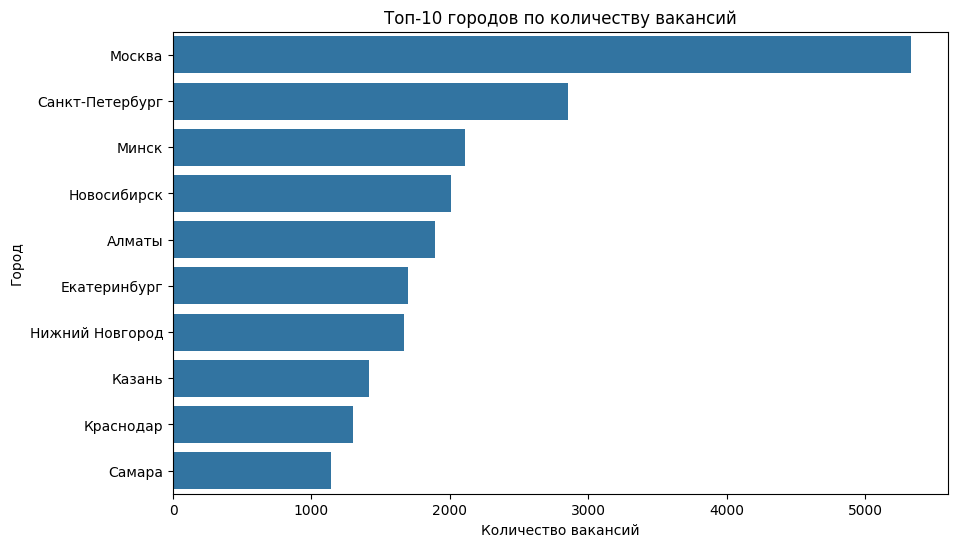

In [14]:
# результат запроса
# Наибольшее количество вакансий в базе данных размещено в Москве, с большим отрывом от остальных городов. Далее идут Санкт-Петербург, Новосибирск, Екатеринбург 
# и другие крупные города.

# результаты нагляднее представить в виде диаграммы
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(data=df_4_1, x='cnt', y='area')
plt.title('Топ-10 городов по количеству вакансий')
plt.xlabel('Количество вакансий')
plt.ylabel('Город')
plt.show()  

2. Напишите запрос, чтобы определить у какого количества вакансий заполнено хотя бы одно из двух полей с зарплатой.

In [15]:
# текст запроса
query_4_2 = f'''    
SELECT
    COUNT(*) AS cnt
FROM
    VACANCIES
WHERE
    salary_from IS NOT NULL OR salary_to IS NOT NULL
'''
# используем метод read_sql_query, чтобы получить результаты запроса сразу в виде датафрейма
df_4_2 = pd.read_sql_query(query_4_2, connection)
df_4_2

/tmp/ipykernel_12276/2672178026.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_4_2 = pd.read_sql_query(query_4_2, connection)


,cnt
0,24073


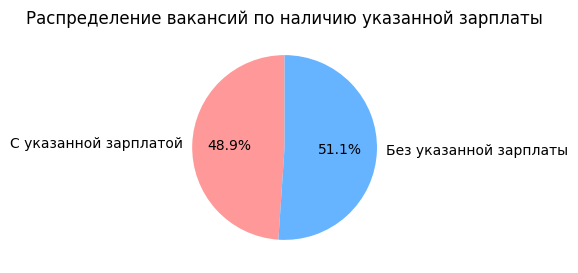

In [16]:
# результат запроса
# Всего в базе данных 49197 вакансий, из них с указанной зарплатой 29231 (49%).
# Данные можно представить в виде диаграммы
labels = ['С указанной зарплатой', 'Без указанной зарплаты']
sizes = [df_4_2['cnt'][0], df_3_1['count'][0] - df_4_2['cnt'][0]]
colors = ['#ff9999','#66b3ff']
plt.figure(figsize=(3,3))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Распределение вакансий по наличию указанной зарплаты')
plt.show()

3. Найдите средние значения для нижней и верхней границы зарплатной вилки. Округлите значения до целого.

In [17]:
# текст запроса
query_4_3 = f'''    
SELECT
    ROUND(AVG(salary_from)) AS avg_salary_from,
    ROUND(AVG(salary_to)) AS avg_salary_to
FROM
    VACANCIES;
'''

# используем метод read_sql_query, чтобы получить результаты запроса сразу в виде датафрейма
df_4_3 = pd.read_sql_query(query_4_3, connection)
df_4_3


/tmp/ipykernel_12276/1911451844.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_4_3 = pd.read_sql_query(query_4_3, connection)


,avg_salary_from,avg_salary_to
0,71065.0,110537.0


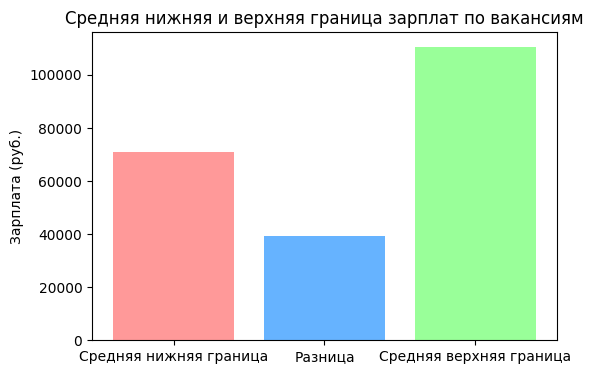

In [18]:
# результат запроса
# Результаты запроса показывают, что средняя нижняя граница зарплат по вакансиям в базе данных составляет 71065 рублей, а средняя верхняя граница - 110537 рублей.
# Можно предоставить эти данные в виде диаграммы:
labels = ['Средняя нижняя граница', 'Разница', 'Средняя верхняя граница']

avg_from = df_4_3['avg_salary_from'][0]
avg_to   = df_4_3['avg_salary_to'][0]
diff     = avg_to - avg_from

sizes = [avg_from, diff, avg_to]
colors = ['#ff9999','#66b3ff', '#99ff99']
plt.figure(figsize=(6,4))
plt.bar(labels, sizes, color=colors)
plt.title('Средняя нижняя и верхняя граница зарплат по вакансиям')
plt.ylabel('Зарплата (руб.)')
plt.show()  





4. Напишите запрос, который выведет количество вакансий для каждого сочетания типа рабочего графика (schedule) и типа трудоустройства (employment), используемого в вакансиях. Результат отсортируйте по убыванию количества.


In [19]:
# текст запроса
query_4_4 = f'''    
SELECT
    schedule,
    employment,
    COUNT(id) AS qnt
FROM
    VACANCIES
GROUP BY
    schedule, employment
ORDER BY
    qnt DESC
'''
# используем метод read_sql_query, чтобы получить результаты запроса сразу в виде датафрейма
df_4_4 = pd.read_sql_query(query_4_4, connection)
df_4_4

/tmp/ipykernel_12276/3775438642.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_4_4 = pd.read_sql_query(query_4_4, connection)


,schedule,employment,qnt
0,Полный день,Полная занятость,35367
1,Удаленная работа,Полная занятость,7802
2,Гибкий график,Полная занятость,1593
3,Удаленная работа,Частичная занятость,1312
4,Сменный график,Полная занятость,940
5,Полный день,Стажировка,569
6,Вахтовый метод,Полная занятость,367
7,Полный день,Частичная занятость,347
8,Гибкий график,Частичная занятость,312
9,Полный день,Проектная работа,141


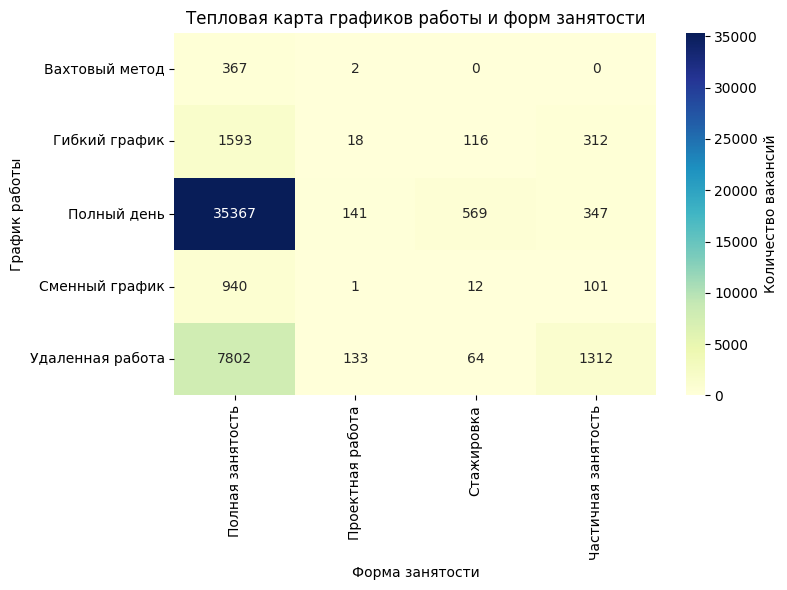

In [20]:
# результат запроса
# сводная таблица
pivot_df = df_4_4.pivot(index="schedule", columns="employment", values="qnt").fillna(0)

plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot_df,
    annot=True, fmt="g", cmap="YlGnBu",
    cbar_kws={"label": "Количество вакансий"}
)

plt.title("Тепловая карта графиков работы и форм занятости")
plt.xlabel("Форма занятости")
plt.ylabel("График работы")
plt.tight_layout()
plt.show()


# Вывод
# Наиболее распространенный график работы - полный день, наиболее распространенная форма занятости - полная занятость. 
# Следующие по популярности - удаленная работа и полная занятость.


5. Напишите запрос, выводящий значения поля Требуемый опыт работы (experience) в порядке возрастания количества вакансий, в которых указан данный вариант опыта. 

In [21]:
# текст запроса
query_4_5 = f'''    
SELECT
    experience,
    COUNT(id) AS qnt
FROM
    VACANCIES
GROUP BY
    experience
ORDER BY
    qnt ASC
'''
# используем метод read_sql_query, чтобы получить результаты запроса сразу в виде датафрей
df_4_5 = pd.read_sql_query(query_4_5, connection)
df_4_5


/tmp/ipykernel_12276/208043367.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_4_5 = pd.read_sql_query(query_4_5, connection)


,experience,qnt
0,Более 6 лет,1337
1,Нет опыта,7197
2,От 3 до 6 лет,14511
3,От 1 года до 3 лет,26152


In [22]:
# результат запроса

# Наиболее распространенный уровень опыта по возрастанию  - "От 1 года до 3",  "От 3 года до 6 лет "Нет опыта", затем "Более 6 лет".

***

In [23]:
# выводы по детальному анализу вакансий
# В Алмате окахывается хорошо жить))) Уровень зарплат в среднем соответстует уровню крупных городов
# 51 % не указали уровень ЗП на что затрудняет анализ
# Наиболее распространенный уровень опыта - "От 1 года до 3" 

# Юнит 5. Анализ работодателей

1. Напишите запрос, который позволит узнать, какие работодатели находятся на первом и пятом месте по количеству вакансий.

In [24]:
# текст запроса
query_5_1 = f'''
SELECT
    e.name AS employer,
    COUNT(v.id) AS qnt
FROM
    VACANCIES v
JOIN
    EMPLOYERS e ON v.employer_id = e.id
GROUP BY
    e.name
ORDER BY
    qnt DESC
LIMIT 10
'''
# используем метод read_sql_query, чтобы получить результаты запроса сразу в виде датафрейма
df_5_1 = pd.read_sql_query(query_5_1, connection)
# первая и пятая строки
df_5_1.iloc[[0, 4]]


/tmp/ipykernel_12276/1971667358.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5_1 = pd.read_sql_query(query_5_1, connection)


,employer,qnt
0,Яндекс,1933
4,Газпром нефть,331


In [25]:
# результат запроса
# на первом месте - Яндекс,
# на пятом - Газпром нефть

2. Напишите запрос, который для каждого региона выведет количество работодателей и вакансий в нём.
Среди регионов, в которых нет вакансий, найдите тот, в котором наибольшее количество работодателей.


In [26]:
# The SQL query is correct, so no changes are needed there.
query_5_2 = f'''
WITH stats AS (
    SELECT 
        a.id AS area_id,
        a.name AS area_name,
        COUNT(DISTINCT e.id) AS employers_cnt,
        COUNT(DISTINCT v.id) AS vacancies_cnt
    FROM areas a
    LEFT JOIN employers e ON a.id = e.area
    LEFT JOIN vacancies v ON a.id = v.area_id
    GROUP BY a.id, a.name
)
SELECT *
FROM stats
WHERE vacancies_cnt = 0
ORDER BY employers_cnt DESC
LIMIT 10;


'''
# используем метод read_sql_query, чтобы получить результаты запроса сразу в виде датафрейма
df_5_2 = pd.read_sql_query(query_5_2, connection)
df_5_2

/tmp/ipykernel_12276/3424278114.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5_2 = pd.read_sql_query(query_5_2, connection)


,area_id,area_name,employers_cnt,vacancies_cnt
0,113,Россия,410,0
1,40,Казахстан,207,0
2,2019,Московская область,75,0
3,1438,Краснодарский край,19,0
4,16,Беларусь,18,0
5,1530,Ростовская область,18,0
6,9,Азербайджан,17,0
7,1679,Нижегородская область,16,0
8,1624,Республика Татарстан,16,0
9,97,Узбекистан,15,0


In [27]:
# результат запроса
# Если не считать Государства целиком то лидирует Московская область и Краснодарский край (В этих регионах много компаний, но нет вакансий в базе данных).

3. Для каждого работодателя посчитайте количество регионов, в которых он публикует свои вакансии. Отсортируйте результат по убыванию количества.


In [28]:
# текст запроса
query_5_3 = f'''
SELECT 
    e.name AS employer_name,
    COUNT(DISTINCT v.area_id) AS regions_count
FROM 
    employers e
JOIN 
    vacancies v ON e.id = v.employer_id
GROUP BY 
    e.id, e.name
ORDER BY 
    regions_count DESC
LIMIT 5;

'''
# используем метод read_sql_query, чтобы получить результаты запроса сразу в виде датафрейма
df_5_3 = pd.read_sql_query(query_5_3, connection)
df_5_3

/tmp/ipykernel_12276/221446849.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5_3 = pd.read_sql_query(query_5_3, connection)


,employer_name,regions_count
0,Яндекс,181
1,Ростелеком,152
2,Спецремонт,116
3,Поляков Денис Иванович,88
4,ООО ЕФИН,71


In [29]:
# результат запроса
# Наибольшее количество регионов охватывает компания "Яндекс" - 181 регион, на втором месте "Ростелеком" - 152 

4. Напишите запрос для подсчёта количества работодателей, у которых не указана сфера деятельности. 

In [30]:
# текст запроса
query_5_4 = f'''
SELECT 
    COUNT(*) AS employers_without_industry
FROM 
    employers e
LEFT JOIN
    employers_industries ei ON e.id = ei.employer_id
WHERE
    ei.industry_id IS NULL;
'''
# используем метод read_sql_query, чтобы получить результаты запроса сразу в виде датафрейма
df_5_4 = pd.read_sql_query(query_5_4, connection)
df_5_4

    

/tmp/ipykernel_12276/3401854050.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5_4 = pd.read_sql_query(query_5_4, connection)


,employers_without_industry
0,8419


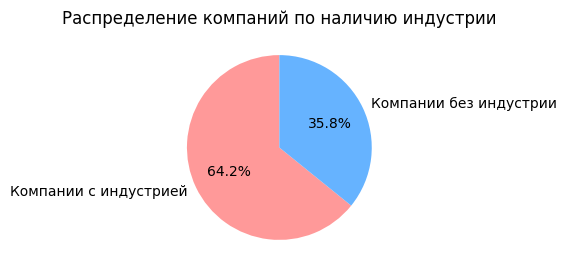

In [31]:
# результат запроса

# Данные целесообразно представить в виде графика
labels = ['Компании с индустрией', 'Компании без индустрии']
sizes = [df_3_2['count'][0] - df_5_4['employers_without_industry'][0], df_5_4['employers_without_industry'][0]]
colors = ['#ff9999','#66b3ff']
plt.figure(figsize=(3,3))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Распределение компаний по наличию индустрии')
plt.show()      

# Как видно из диаграммы, 36% компаний в базе данных не указали свою индустрию.

5. Напишите запрос, чтобы узнать название компании, находящейся на третьем месте в алфавитном списке (по названию) компаний, у которых указано четыре сферы деятельности. 

In [32]:
# текст запроса
query_5_5 = f'''
SELECT 
    e.name AS employer_name
FROM 
    employers e
LEFT JOIN
    employers_industries ei ON e.id = ei.employer_id
LEFT JOIN
    industries i ON ei.industry_id = i.id
GROUP BY 
    e.id, e.name
HAVING 
    COUNT(i.id) = 4
ORDER BY 
    employer_name ASC
LIMIT 1 OFFSET 2;


'''
# используем метод read_sql_query, чтобы получить результаты запроса сразу в виде датафрейма
df_5_5 = pd.read_sql_query(query_5_5, connection)
# вывести четвёртую строку
df_5_5


/tmp/ipykernel_12276/4194417667.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5_5 = pd.read_sql_query(query_5_5, connection)


,employer_name
0,2ГИС


In [33]:
# результат запроса
# Компания "2ГИС" указала ровно 4 индустрии, находится на 3м месте в алфавитном порядке.

6. С помощью запроса выясните, у какого количества работодателей в качестве сферы деятельности указана Разработка программного обеспечения.


In [34]:
# текст запроса
query_5_6 = f'''
SELECT 
    COUNT(DISTINCT e.id) AS employers_count
FROM
    employers e
JOIN
    employers_industries ei ON e.id = ei.employer_id
JOIN 
    industries i ON ei.industry_id = i.id
WHERE
    i.name = 'Разработка программного обеспечения';
'''
# используем метод read_sql_query, чтобы получить результаты запроса сразу в виде датафрейма
df_5_6 = pd.read_sql_query(query_5_6, connection)
df_5_6


/tmp/ipykernel_12276/3804258311.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5_6 = pd.read_sql_query(query_5_6, connection)


,employers_count
0,3553


In [35]:
# результат запроса
# Всего 3553 работодателя указали индустрию "Разработка программного обеспечения".

7. Для компании «Яндекс» выведите список регионов-миллионников, в которых представлены вакансии компании, вместе с количеством вакансий в этих регионах. Также добавьте строку Total с общим количеством вакансий компании. Результат отсортируйте по возрастанию количества.

Список городов-милионников надо взять [отсюда](https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D0%B4%D0%B0-%D0%BC%D0%B8%D0%BB%D0%BB%D0%B8%D0%BE%D0%BD%D0%B5%D1%80%D1%8B_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8). 

Если возникнут трудности с этим задание посмотрите материалы модуля  PYTHON-17. Как получать данные из веб-источников и API. 

In [36]:
# код для получения списка городов-милионников

import requests
from bs4 import BeautifulSoup

API_URL = 'https://ru.wikipedia.org/w/api.php'

params = {
    'action': 'parse',
    'page': 'Города-миллионеры_России',
    'prop': 'text',
    'format': 'json'
}

headers = {
    "User-Agent": "MyApp/1.0 (example@example.com)"
}

resp = requests.get(API_URL, params=params, headers=headers)
resp.raise_for_status()

data = resp.json()
html_content = data['parse']['text']['*']

soup = BeautifulSoup(html_content, 'html.parser')

cities = []

# Берём первую таблицу на странице
table = soup.find('table')

if table:
    for row in table.find_all('tr')[1:]:
        cols = row.find_all('td')
        if len(cols) > 1:
            city_name = cols[1].get_text(strip=True)
            cities.append(city_name)

print(cities)

# превращаем список в строку для SQL
cities_str = "', '".join(cities)



['Москва', 'Санкт-Петербург', 'Новосибирск', 'Екатеринбург', 'Казань', 'Красноярск', 'Нижний Новгород', 'Челябинск', 'Уфа', 'Краснодар', 'Самара', 'Ростов-на-Дону', 'Омск', 'Воронеж', 'Пермь', 'Волгоград']


In [37]:
# текст запроса

query_5_7 = f"""
WITH city_vacancies AS (
    SELECT
        A.name AS city,
        COUNT(V.id) AS vacancies_count
    FROM VACANCIES AS V
    JOIN AREAS AS A ON V.area_id = A.id
    JOIN EMPLOYERS AS E ON V.employer_id = E.id
    WHERE E.name = 'Яндекс'
      AND A.name IN ('{cities_str}')
    GROUP BY A.name
)
SELECT city, vacancies_count, 0 AS sort_order
FROM city_vacancies
UNION ALL
SELECT 'Total', SUM(vacancies_count), 1
FROM city_vacancies
ORDER BY sort_order, vacancies_count;
"""

df_5_7 = pd.read_sql_query(query_5_7, connection)
df_5_7


/tmp/ipykernel_12276/2974341861.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5_7 = pd.read_sql_query(query_5_7, connection)


,city,vacancies_count,sort_order
0,Омск,21.0,0
1,Челябинск,22.0,0
2,Красноярск,23.0,0
3,Волгоград,24.0,0
4,Пермь,25.0,0
5,Казань,25.0,0
6,Ростов-на-Дону,25.0,0
7,Самара,26.0,0
8,Уфа,26.0,0
9,Краснодар,30.0,0


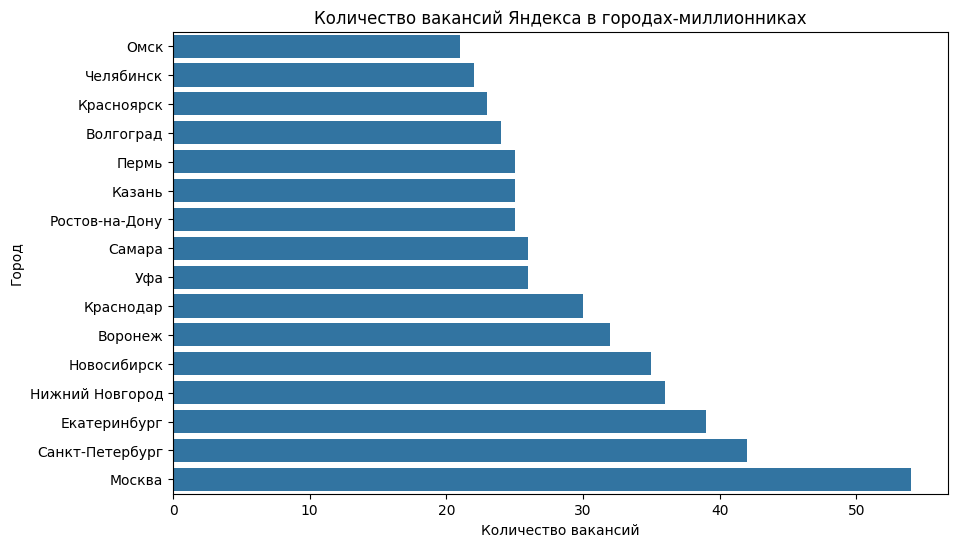

In [38]:
# результат запроса

# Данные целесообразно представить в виде диаграммы
plt.figure(figsize=(10,6))
sns.barplot(data=df_5_7[df_5_7['city'] != 'Total'], x='vacancies_count', y='city')
plt.title('Количество вакансий Яндекса в городах-миллионниках')
plt.xlabel('Количество вакансий')
plt.ylabel('Город')
plt.show()  

***

In [39]:
# выводы по анализу работодателей
# 36% компаний в базе данных не указали свою индустрию.
# Компания "2ГИС" указала ровно 4 индустрии, находится на 3м месте в алфавитном порядке.
# Наибольшее количество регионов охватывает компания "Яндекс" - 181 регион, на втором месте "Ростелеком" - 152 
# Если не считать Государства целиком то лидирует Московская область и Краснодарский край (В этих регионах много компаний, но нет вакансий в базе данных).
# Всего 3553 работодателя указали индустрию "Разработка программного обеспечения".
# В Московской области и Краснодарском крае много компаний, но нет вакансий в базе данных.


# Юнит 6. Предметный анализ

1. Сколько вакансий имеет отношение к данным?

Считаем, что вакансия имеет отношение к данным, если в её названии содержатся слова 'data' или 'данн'.

*Подсказка: Обратите внимание, что названия вакансий могут быть написаны в любом регистре.* 


In [76]:
query_6_1 = f'''
SELECT
    COUNT(*)
FROM
    VACANCIES
WHERE
    LOWER(name) LIKE '%data%' OR LOWER(name) LIKE '%данн%';
'''

# используем метод read_sql_query, чтобы получить результаты запроса сразу в виде датафрейма
df_6_1 = pd.read_sql_query(query_6_1, connection)
df_6_1

/tmp/ipykernel_12276/3497933949.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_6_1 = pd.read_sql_query(query_6_1, connection)


,count
0,1771


In [77]:
# результат запроса - 1771

2. Сколько есть подходящих вакансий для начинающего дата-сайентиста? 
Будем считать вакансиями для дата-сайентистов такие, в названии которых есть хотя бы одно из следующих сочетаний:
* 'data scientist'
* 'data science'
* 'исследователь данных'
* 'ML' (здесь не нужно брать вакансии по HTML)
* 'machine learning'
* 'машинн%обучен%'

** В следующих заданиях мы продолжим работать с вакансиями по этому условию.*

Считаем вакансиями для специалистов уровня Junior следующие:
* в названии есть слово 'junior' *или*
* требуемый опыт — Нет опыта *или*
* тип трудоустройства — Стажировка.
 

In [78]:
# текст запроса

query_6_2 = f'''
SELECT 
    COUNT(*) AS junior_ds_vacancies
FROM 
    vacancies v
WHERE 
(
    LOWER(v.name) LIKE '%data scientist%'
 OR LOWER(v.name) LIKE '%data science%'
 OR LOWER(v.name) LIKE '%исследователь данных%'
 OR (v.name LIKE '%ML%' AND v.name NOT LIKE '%HTML%')
 OR LOWER(v.name) LIKE '%machine learning%'
 OR LOWER(v.name) LIKE '%машинн%обучен%'
)
AND 
(
    LOWER(v.name) LIKE '%junior%'
 OR v.experience = 'Нет опыта'
 OR v.employment = 'Стажировка'
);
'''
# используем метод read_sql_query, чтобы получить результаты запроса сразу в виде датафрейма
df_6_2 = pd.read_sql_query(query_6_2, connection)
df_6_2


/tmp/ipykernel_12276/1773528235.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_6_2 = pd.read_sql_query(query_6_2, connection)


,junior_ds_vacancies
0,51


In [79]:
# результат запроса
# Всего 51 вакансий для начинающих специалистов в области Data Science.

3. Сколько есть вакансий для DS, в которых в качестве ключевого навыка указан SQL или postgres?

** Критерии для отнесения вакансии к DS указаны в предыдущем задании.*

In [80]:
query_6_3 = f'''
SELECT
    COUNT(*)
FROM
    VACANCIES
WHERE
    (
           LOWER(name) LIKE '%data scientist%'
        OR LOWER(name) LIKE '%data science%'
        OR LOWER(name) LIKE '%исследователь данных%'
        OR (LOWER(name) LIKE '%ml%' AND LOWER(name) NOT LIKE '%html%')
        OR LOWER(name) LIKE '%machine learning%'
        OR LOWER(name) LIKE '%машинн%обучен%'
    )
    AND
    (
           LOWER(key_skills) LIKE '%sql%'
        OR LOWER(key_skills) LIKE '%postgres%'
    );
'''

# используем метод read_sql_query, чтобы получить результаты запроса сразу в виде датафрейма
df_6_3 = pd.read_sql_query(query_6_3, connection)
df_6_3

/tmp/ipykernel_12276/2498742423.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_6_3 = pd.read_sql_query(query_6_3, connection)


,count
0,229


In [81]:
# результат запроса - 229

4. Проверьте, насколько популярен Python в требованиях работодателей к DS.Для этого вычислите количество вакансий, в которых в качестве ключевого навыка указан Python.

** Это можно сделать помощью запроса, аналогичного предыдущему.*

In [82]:
# текст запроса
query_6_4 = f'''
SELECT
    COUNT(*)
FROM
    VACANCIES
WHERE
    LOWER(key_skills) LIKE '%python%'
    AND
    (
           LOWER(name) LIKE '%data scientist%'
        OR LOWER(name) LIKE '%data science%'
        OR LOWER(name) LIKE '%исследователь данных%'
        OR (LOWER(name) LIKE '%ml%' AND LOWER(name) NOT LIKE '%html%')
        OR LOWER(name) LIKE '%machine learning%'
        OR LOWER(name) LIKE '%машинн%обучен%'
    );
'''

df_6_4 = pd.read_sql_query(query_6_4, connection)
df_6_4

/tmp/ipykernel_12276/1742880256.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_6_4 = pd.read_sql_query(query_6_4, connection)


,count
0,357


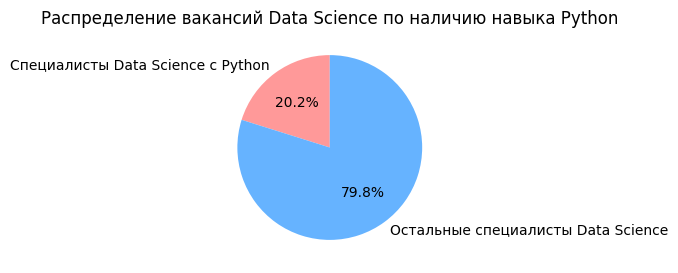

In [83]:
# результат запроса

# 357 вакансий для специалистов Data Science с ключевым навыком Python.
# сравнить с общим количеством вакансий для специалистов Data Science - 1771 в виде графика
labels = ['Специалисты Data Science с Python', 'Остальные специалисты Data Science']
sizes = [df_6_4['count'][0], df_6_1['count'][0] - df_6_4['count'][0]]
colors = ['#ff9999','#66b3ff']
plt.figure(figsize=(3,3))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Распределение вакансий Data Science по наличию навыка Python')
plt.show()  

5. Сколько ключевых навыков в среднем указывают в вакансиях для DS?
Ответ округлите до двух знаков после точки-разделителя.

In [100]:
# текст запроса

query_6_5 = f'''
WITH ds_vacancies AS (
    SELECT 
        id,
        key_skills
    FROM vacancies
    WHERE 
           name ILIKE '%data scientist%'
        OR name ILIKE '%data science%'
        OR name ILIKE '%исследователь данных%'
        OR (name ILIKE '%ML%' AND name NOT ILIKE '%HTML%')
        OR name ILIKE '%machine learning%'
        OR name ILIKE '%машинн%обучен%'
)
SELECT 
    ROUND(AVG(skills_count)::numeric, 2) AS avg_skills
FROM (
    SELECT
        id,
        CASE 
            WHEN key_skills IS NULL OR key_skills = '' THEN 0
            ELSE (LENGTH(key_skills) - LENGTH(REPLACE(key_skills, E'\t', ''))) + 1
        END AS skills_count
    FROM ds_vacancies
) t;

'''

df_6_5 = pd.read_sql_query(query_6_5, connection)
df_6_5

/tmp/ipykernel_12276/489609590.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_6_5 = pd.read_sql_query(query_6_5, connection)


,avg_skills
0,5.88


In [ ]:
# результат запроса
# Всего 5.88 навыков в среднем требуется в вакансиях для специалистов Data Science.

6. Напишите запрос, позволяющий вычислить, какую зарплату для DS в **среднем** указывают для каждого типа требуемого опыта (уникальное значение из поля *experience*). 

При решении задачи примите во внимание следующее:
1. Рассматриваем только вакансии, у которых заполнено хотя бы одно из двух полей с зарплатой.
2. Если заполнены оба поля с зарплатой, то считаем зарплату по каждой вакансии как сумму двух полей, делённую на 2. Если заполнено только одно из полей, то его и считаем зарплатой по вакансии.
3. Если в расчётах участвует null, в результате он тоже даст null (посмотрите, что возвращает запрос select 1 + null). Чтобы избежать этой ситуацию, мы воспользуемся функцией [coalesce](https://postgrespro.ru/docs/postgresql/9.5/functions-conditional#functions-coalesce-nvl-ifnull), которая заменит null на значение, которое мы передадим. Например, посмотрите, что возвращает запрос `select 1 + coalesce(null, 0)`

Выясните, на какую зарплату в среднем может рассчитывать дата-сайентист с опытом работы от 3 до 6 лет. Результат округлите до целого числа. 

In [105]:
# текст запроса
query_6_6 = f'''
WITH salaries AS (
    SELECT
        experience,
        CASE
            WHEN salary_from IS NOT NULL AND salary_to IS NOT NULL
                 THEN (salary_from + salary_to) / 2
            ELSE COALESCE(salary_from, salary_to)
        END AS salary
    FROM vacancies
    WHERE salary_from IS NOT NULL OR salary_to IS NOT NULL
)
SELECT
    experience,
    ROUND(AVG(salary)) AS avg_salary
FROM salaries
GROUP BY experience
ORDER BY experience;

'''

df_6_6 = pd.read_sql_query(query_6_6, connection)
df_6_6

/tmp/ipykernel_12276/3603209957.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_6_6 = pd.read_sql_query(query_6_6, connection)


,experience,avg_salary
0,Более 6 лет,166256.0
1,Нет опыта,40472.0
2,От 1 года до 3 лет,76541.0
3,От 3 до 6 лет,133211.0


In [ ]:
# результат запроса
# Зарплаты по вакансиям для специалистов с опытом работы "3 - 6 лет" - 133211 



/tmp/ipykernel_12276/519194770.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_6_6, connection)


,round
0,256454.0


***

In [ ]:
# выводы по предметному анализу

# Всего 1771 вакансий для специалистов в области Data Science, из них 51 вакансия для начинающих специалистов.
# 229 вакансий для специалистов Data Science с ключевым навыком SQL.
# 357 вакансий для специалистов Data Science с ключевым навыком Python.
# Всего 5.88 навыков в среднем требуется в вакансиях для специалистов Data Science.
# Зарплаты по вакансиям для специалистов с опытом работы "3 - 6 лет" - 133211 рублей

# Общий вывод по проекту

In [ ]:
# подведем итог исследования, обобщите выводы
# здесь можно (это будет плюсом) провести дополнительные исследования данных, сделать прогнозы, продумать варианты продолжения исследования
# Всего в базе данных 49197 вакансий от 2358 компаний. Вакансии размещены в 1364 регионах (городах) и относятся к 294 индустриям.
# Наибольшее количество вакансий в базе данных размещено в Москве, с большим отрывом от остальных городов. Далее идут Санкт-Петербург, Новосибирск, Екатеринбург
# 51 % не указали уровень ЗП на что затрудняет анализ
# Наиболее распространенный уровень опыта - "От 1 года до 3"
# 36% компаний в базе данных не указали свою индустрию.
# Компания "2ГИС" указала ровно 4 индустрии, находится на
# 3м месте в алфавитном порядке.
# Наибольшее количество регионов охватывает компания "Яндекс" - 181 регион, на втором месте "Ростелеком" - 152
# Если не считать Государства целиком то лидирует Московская область и Краснодарский край (В этих регионах много компаний, но нет вакансий в базе данных).
# Всего 3553 работодателя указали индустрию "Разработка программного обеспечения".
# В Московской области и Краснодарском крае много компаний, но нет вакансий в базе данных.
# Всего 1771 вакансий для специалистов в области Data Science, из них 51 вакансия для начинающих специалистов.
# 229 вакансий для специалистов Data Science с ключевым навыком SQL.
# 357 вакансий для специалистов Data Science с ключевым навыком Python.
# Всего 5.88 навыков в среднем требуется в вакансиях для специалистов Data Science.
# Зарплаты по вакансиям для специалистов с опытом работы "3 - 6 лет" - 133211 рублей